FILTERING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from pathlib import Path
from sklearn.metrics import pairwise_distances_argmin_min
import shutil
import hdbscan
from sklearn.metrics import silhouette_score, silhouette_samples
import sys
from sklearn.feature_selection import VarianceThreshold
import umap
from sklearn.metrics import pairwise_distances
from sklearn import set_config
import os
from sklearn.model_selection import ParameterSampler
from matplotlib.colors import SymLogNorm

c:\Users\chris\Desktop\Fase2Tesi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.set_printoptions(threshold=sys.maxsize)
# Imposta l'output a 'pandas' per tutto lo script
set_config(transform_output='pandas')

NOISE_REDUCTION=False
noise_reduction_str="[NOISE_REDUCTION]" * NOISE_REDUCTION
HIGH_PASS_FILTER=False
high_pass_filter_str="[HIGH_PASS_FILTER]" * HIGH_PASS_FILTER

AUDIO_FEATURES_CSV_PATH=Path(f"{noise_reduction_str}{high_pass_filter_str}audio_samples_features_for_filtering.csv")

SOURCE_DIR = Path(f"AudioSamples")
OUTPUT_BASE_DIR = Path(f"{noise_reduction_str}{high_pass_filter_str}Clustered_Audio")
FILTERED_DIR=Path(f"{noise_reduction_str}{high_pass_filter_str}AudioSamplesFiltered")
CSV_METADATA_PATH = Path("audio_samples_metadata.csv")
CSV_OUTPUT_PATH = Path(f"{noise_reduction_str}{high_pass_filter_str}audio_samples_filtered_metadata.csv")

UMAP_FOR_HDBSCAN=False
VARIANZA_SPIEGATA=0.90  #0.90
PREFERRED_CLUSTERING_TECHNIQUE = "k-means"
PREFERRED_CLUSTERS = [0,1]  # Cambia in base al cluster che vuoi filtrare
WANT_TO_SAVE=True


In [3]:
if WANT_TO_SAVE:
    if OUTPUT_BASE_DIR.exists():
        shutil.rmtree(OUTPUT_BASE_DIR)  # Rimuove la cartella e tutto il contenuto

    OUTPUT_BASE_DIR.mkdir(parents=True) # La ricrea vuota

In [4]:
if WANT_TO_SAVE:
    if FILTERED_DIR.exists():
        shutil.rmtree(FILTERED_DIR)  # Rimuove la cartella e tutto il contenuto

    FILTERED_DIR.mkdir(parents=True) # La ricrea vuota

In [5]:
df = pd.read_csv(AUDIO_FEATURES_CSV_PATH, index_col="filename")
metadata_df = pd.read_csv(CSV_METADATA_PATH)

In [6]:
# Identifichiamo le colonne delle feature (tutte tranne il filename)
#features_cols = [c for c in df.columns if c != 'filename']

# 2. Pulizia dei dati
# Gestiamo eventuali valori infiniti o NaN che possono capitare con i Delta
X = df.replace([np.inf, -np.inf], np.nan).fillna(0)

In [7]:
print(f"Numero di feature in X: {X.shape[1]}")

Numero di feature in X: 1206


HDBSCAN (PREFILTRO PER RIMOZIONE OUTLIER)

In [8]:
# 1. Preparazione: Standardizzazione e PCA (fatti una sola volta fuori dal ciclo)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Assumi X come i tuoi dati grezzi

X_final_for_hdbscan=X_scaled

if UMAP_FOR_HDBSCAN:

    reducer = umap.UMAP(
    n_neighbors=10,      # Un valore medio per bilanciare locale e globale
    n_components=10,
    min_dist=0.0,        # Mantiene i cluster densi per facilitare HDBSCAN
    metric='euclidean',     # Ideale per dati audio (cosine)
    random_state=42      # Fondamentale per la riproducibilità
    )

    X_final_for_hdbscan = reducer.fit_transform(X_scaled)

    X_final_for_hdbscan = pd.DataFrame(
        X_final_for_hdbscan,
        columns=[f'umap_{i+1}' for i in range(X_final_for_hdbscan.shape[1])],
        index=X_scaled.index
    )
else:
    pca = PCA(n_components=VARIANZA_SPIEGATA, random_state=42)
    X_final_for_hdbscan = pca.fit_transform(X_scaled)

In [9]:
print(f"Numero di feature in X_final_for_hdbscan: {X_final_for_hdbscan.shape[1]}")

Numero di feature in X_final_for_hdbscan: 25


In [10]:
# 4. Riduzione dimensionalità per il grafico
# PCA aiuta a vedere la struttura globale dei dati
pca_for_viz = PCA(n_components=2, random_state=42)
pca_coords = pca_for_viz.fit_transform(X_scaled)
df_for_viz = X_final_for_hdbscan.copy()
df_for_viz['pca_1'] = pca_coords.iloc[:, 0]
df_for_viz['pca_2'] = pca_coords.iloc[:, 1]

In [11]:
# 1. Definisci lo spazio dei parametri da esplorare
param_grid = {
    'min_cluster_size': range(20, 80),
    'min_samples': range(5, 20),
    'cluster_selection_epsilon': [0.0, 0.1, 0.2]
}

# 2. Crea un generatore di parametri random
param_list = list(ParameterSampler(param_grid, n_iter=100, random_state=42))

best_score = -1
best_params = None

# 3. Ciclo di ricerca manuale
for params in param_list:
    clusterer = hdbscan.HDBSCAN(**params)
    labels = clusterer.fit_predict(X_final_for_hdbscan) # X_scaled è il tuo dataset preparato

    # Escludi il rumore (-1) dal calcolo della silhouette
    mask = labels != -1
    if len(np.unique(labels[mask])) > 1:  # Serve almeno un cluster per calcolare la silhouette
        score = silhouette_score(X_final_for_hdbscan[mask], labels[mask])
        print(f"Eseguito HDBSCAN con i seguenti parametri: {params}")
        print(f"Silhouette score: {score}")


        if score > best_score:
            best_score = score
            best_params = params

print(f"Miglior Silhouette Score: {best_score}")
print(f"Migliori parametri: {best_params}")

Eseguito HDBSCAN con i seguenti parametri: {'min_samples': 9, 'min_cluster_size': 49, 'cluster_selection_epsilon': 0.1}
Silhouette score: 0.4385823594232307
Eseguito HDBSCAN con i seguenti parametri: {'min_samples': 12, 'min_cluster_size': 41, 'cluster_selection_epsilon': 0.1}
Silhouette score: 0.4430160476158922
Eseguito HDBSCAN con i seguenti parametri: {'min_samples': 16, 'min_cluster_size': 33, 'cluster_selection_epsilon': 0.1}
Silhouette score: 0.44611877230883423
Eseguito HDBSCAN con i seguenti parametri: {'min_samples': 7, 'min_cluster_size': 74, 'cluster_selection_epsilon': 0.0}
Silhouette score: 0.43502997557158113
Eseguito HDBSCAN con i seguenti parametri: {'min_samples': 6, 'min_cluster_size': 42, 'cluster_selection_epsilon': 0.1}
Silhouette score: 0.4325024211557812
Eseguito HDBSCAN con i seguenti parametri: {'min_samples': 15, 'min_cluster_size': 57, 'cluster_selection_epsilon': 0.0}
Silhouette score: 0.44589600751368863
Eseguito HDBSCAN con i seguenti parametri: {'min_sam

In [12]:
# 4. HDBSCAN Clustering
hdbscan_clusterer = hdbscan.HDBSCAN(
    **best_params
)
df['cluster_hdbscan'] = hdbscan_clusterer.fit_predict(X_final_for_hdbscan)

C:\Users\chris\AppData\Local\Temp\ipykernel_7624\300418084.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_hdbscan'] = hdbscan_clusterer.fit_predict(X_final_for_hdbscan)


In [13]:
# 2. Calcolo per HDBSCAN (Attenzione al rumore)
# Il Silhouette score non è definito per i punti di rumore (-1).
# Dobbiamo filtrarli per avere un valore significativo sui cluster trovati.
hdb_labels = df['cluster_hdbscan']
mask = hdb_labels != -1
if mask.any():
    score_hdbscan = silhouette_score(X_final_for_hdbscan[mask], hdb_labels[mask])
    print(f"Silhouette Score HDBSCAN (escluso rumore): {score_hdbscan:.4f}")
else:
    print("HDBSCAN non ha trovato cluster (tutto rumore).")

Silhouette Score HDBSCAN (escluso rumore): 0.4465


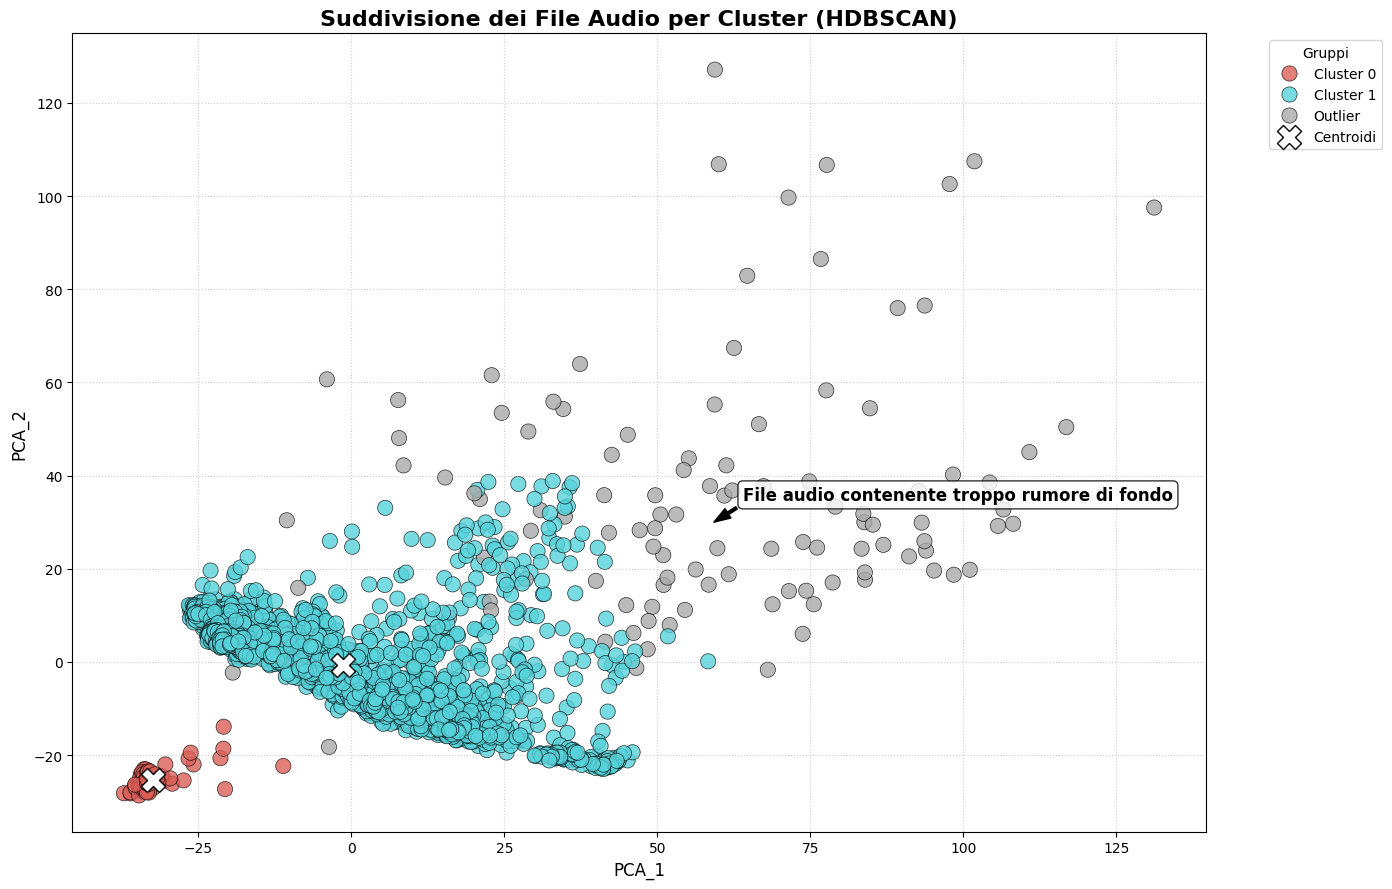

In [14]:
df_for_viz['cluster_hdbscan']=df['cluster_hdbscan']

# Creazione colonna legenda
df_for_viz['legenda_cluster_hdbscan'] = df_for_viz['cluster_hdbscan'].apply(
    lambda x: 'Outlier' if x == -1 else f'Cluster {x}'
)

# --- CONFIGURAZIONE COLORI VIVACI ---
# Otteniamo la lista dei cluster reali (escludendo l'outlier per la palette)
nomi_cluster_reali = sorted([n for n in df_for_viz['legenda_cluster_hdbscan'].unique() if n != 'Outlier'])
n_reali = len(nomi_cluster_reali)

# Generiamo colori molto saturi (HLS è ottimo per colori vividi)
colori_vividi = sns.color_palette("hls", n_reali)

# Costruiamo il dizionario finale
color_dict = {nome: colori_vividi[i] for i, nome in enumerate(nomi_cluster_reali)}
color_dict['Outlier'] = '#A9A9A9'  # Grigio scuro per contrasto con i colori accesi

# --- 5. Visualizzazione ---
plt.figure(figsize=(14, 9))

# Scatter plot con colori saturati
sns.scatterplot(
    x="pca_1",
    y="pca_2",
    hue="legenda_cluster_hdbscan",
    palette=color_dict,
    hue_order=nomi_cluster_reali + (['Outlier'] if 'Outlier' in df_for_viz['legenda_cluster_hdbscan'].values else []),
    data=df_for_viz,
    alpha=0.8,         # Aumentata opacità per colori più carichi
    edgecolor='black', # Bordo nero per far "staccare" i punti
    linewidth=0.5,
    s=120              # Punti leggermente più grandi
)

# --- CALCOLO CENTROIDI ---
unique_clusters = [c for c in df_for_viz['cluster_hdbscan'].unique() if c != -1]
if len(unique_clusters) > 0:
    centroids_pca = np.array([
        df_for_viz[df_for_viz['cluster_hdbscan'] == c][['pca_1', 'pca_2']].mean().values
        for c in unique_clusters
    ])

    plt.scatter(
        centroids_pca[:, 0],
        centroids_pca[:, 1],
        s=300,
        c='white',     # Bianco con bordo nero per contrastare i colori vivaci
        marker='X',
        edgecolors='black',
        label='Centroidi',
        zorder=10
    )

# --- ANNOTAZIONE OUTLIER ---
# Calcoliamo il baricentro degli outlier per posizionare la freccia
outliers = df_for_viz[df_for_viz['cluster_hdbscan'] == -1]

if not outliers.empty:
    outlier_center = outliers[['pca_1', 'pca_2']].median().values

    # Definisci qui la tua didascalia
    testo_didascalia = "File audio contenente troppo rumore di fondo"

    plt.annotate(
        testo_didascalia,
        xy=outlier_center,              # Punto dove punta la freccia (il centro degli outlier)
        xytext=(outlier_center[0] + 5, outlier_center[1] + 5), # Posizione del testo (spostato di 5 unità)
        arrowprops=dict(
            facecolor='black',
            shrink=0.05,
            width=2,
            headwidth=8
        ),
        fontsize=12,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
    )

# --- ESTETICA ASSI ---
plt.title("Suddivisione dei File Audio per Cluster (HDBSCAN)", fontsize=16, fontweight='bold')
plt.xlabel("PCA_1", fontsize=12)
plt.ylabel("PCA_2", fontsize=12)

plt.legend(title="Gruppi", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

In [15]:
# Conteggio per HDBSCAN
print("--- CONTEGGIO CAMPIONI: HDBSCAN ---")
print(df['cluster_hdbscan'].value_counts().sort_index().rename(index={-1: 'Outlier'}))

--- CONTEGGIO CAMPIONI: HDBSCAN ---
cluster_hdbscan
Outlier     112
0            87
1          2567
Name: count, dtype: int64


In [16]:
df_cleaned = df[df['cluster_hdbscan'] != -1].copy()
df_outliers = df[df['cluster_hdbscan'] == -1].copy()

#features_cols = [c for c in df_cleaned.columns if c != 'filename']

X_cleaned = df_cleaned.replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. Rimuovi la colonna 'cluster_hdbscan'
X_cleaned = X_cleaned.drop(columns=['cluster_hdbscan'])

# Verifica il risultato
print(f"Righe originali: {X_final_for_hdbscan.shape[0]}")
print(f"Righe dopo il filtraggio: {X_cleaned.shape[0]}")

Righe originali: 2766
Righe dopo il filtraggio: 2654


In [17]:
print(f"Numero di colonne rimanenti: {len(X_cleaned.columns)}")

Numero di colonne rimanenti: 1206


K-Means (FILTRO EFFETTIVO)

In [18]:
# 1. Preparazione: Standardizzazione e PCA (fatti una sola volta fuori dal ciclo)
scaler = StandardScaler()
X_cleaned_scaled = scaler.fit_transform(X_cleaned) # Assumi X_cleaned come i tuoi dati grezzi senza outlier

pca = PCA(n_components=VARIANZA_SPIEGATA, random_state=42) # Manteniamo il 90% della varianza
X_final_for_kmeans = pca.fit_transform(X_cleaned_scaled)

In [19]:
print(f"Numero di feature in X_final_for_kmeans: {X_final_for_kmeans.shape[1]}")
print("Colonne rimanenti dopo PCA:")
print(X_final_for_kmeans.columns.tolist())

Numero di feature in X_final_for_kmeans: 55
Colonne rimanenti dopo PCA:
['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7', 'pca8', 'pca9', 'pca10', 'pca11', 'pca12', 'pca13', 'pca14', 'pca15', 'pca16', 'pca17', 'pca18', 'pca19', 'pca20', 'pca21', 'pca22', 'pca23', 'pca24', 'pca25', 'pca26', 'pca27', 'pca28', 'pca29', 'pca30', 'pca31', 'pca32', 'pca33', 'pca34', 'pca35', 'pca36', 'pca37', 'pca38', 'pca39', 'pca40', 'pca41', 'pca42', 'pca43', 'pca44', 'pca45', 'pca46', 'pca47', 'pca48', 'pca49', 'pca50', 'pca51', 'pca52', 'pca53', 'pca54']


In [20]:
# 2. Ottimizzazione K
k_range = range(2, 16)
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_final_for_kmeans)

    # Silhouette: misura quanto i cluster sono ben separati (-1 a 1, maggiore è meglio)
    score = silhouette_score(X_final_for_kmeans, labels)
    silhouettes.append(score)
    print(f"Per k={k}, Silhouette Score: {score:.3f}")

best_index = np.argmax(silhouettes)
best_k = k_range[best_index]

Per k=2, Silhouette Score: 0.369
Per k=3, Silhouette Score: 0.395
Per k=4, Silhouette Score: 0.402
Per k=5, Silhouette Score: 0.378
Per k=6, Silhouette Score: 0.279
Per k=7, Silhouette Score: 0.284
Per k=8, Silhouette Score: 0.211
Per k=9, Silhouette Score: 0.204
Per k=10, Silhouette Score: 0.193
Per k=11, Silhouette Score: 0.189
Per k=12, Silhouette Score: 0.199
Per k=13, Silhouette Score: 0.189
Per k=14, Silhouette Score: 0.181
Per k=15, Silhouette Score: 0.189


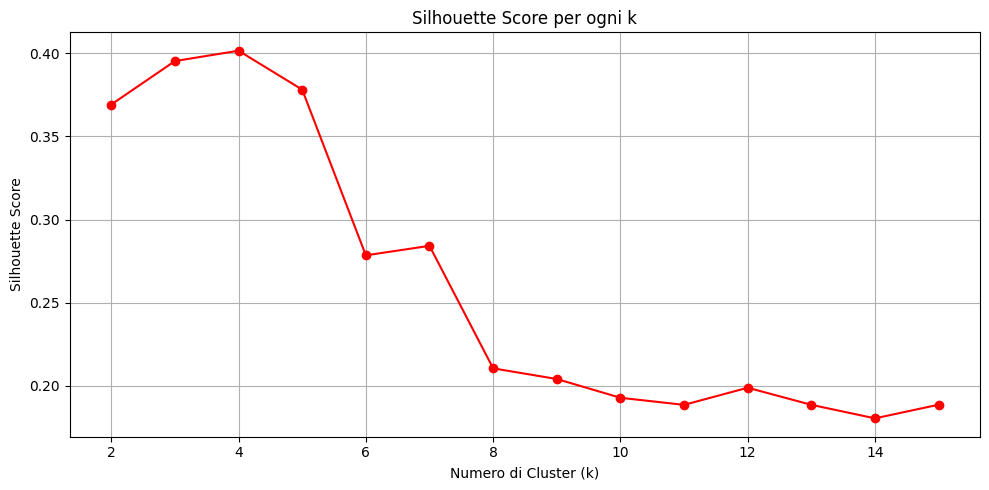

In [21]:
# Crea un singolo grafico
fig, ax = plt.subplots(figsize=(10, 5))

# Usa 'ax' invece di 'ax1'
ax.plot(k_range, silhouettes, 'ro-')
ax.set_title('Silhouette Score per ogni k')
ax.set_xlabel('Numero di Cluster (k)')
ax.set_ylabel('Silhouette Score')
ax.grid(True)

plt.tight_layout()
plt.show()

In [22]:
# 3. K-Means Clustering
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cleaned['cluster_kmeans'] = kmeans.fit_predict(X_final_for_kmeans)

In [23]:
# 4. Riduzione dimensionalità per il grafico
# PCA aiuta a vedere la struttura globale dei dati
pca_for_viz = PCA(n_components=2, random_state=42)
pca_coords = pca_for_viz.fit_transform(X_cleaned_scaled)
df_for_viz = X_final_for_kmeans.copy()
df_for_viz['pca_1'] = pca_coords.iloc[:, 0]
df_for_viz['pca_2'] = pca_coords.iloc[:, 1]

In [24]:
# 4. Calcola la posizione dei centroidi come media dei punti 2D in ogni cluster
df_for_viz['cluster_kmeans'] = df_cleaned['cluster_kmeans']  # Associa il cluster trovato in precedenza
centroids_pca = df_for_viz.groupby('cluster_kmeans')[['pca_1', 'pca_2']].mean().values

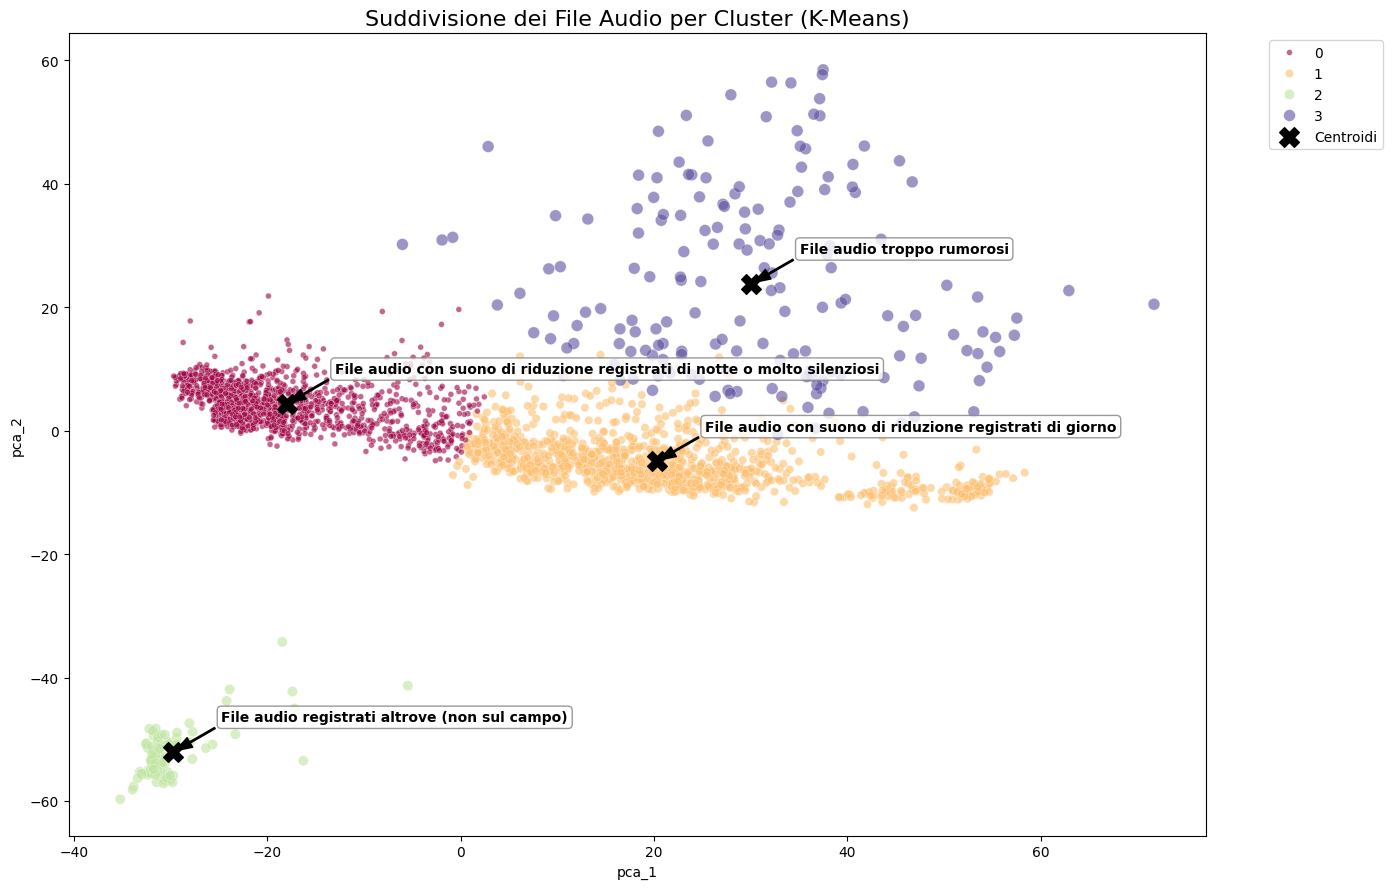

In [25]:
# 5. Visualizzazione Avanzata

plt.figure(figsize=(14, 9))

cluster_labels = {
    0: "File audio con suono di riduzione registrati di notte o molto silenziosi",
    1: "File audio con suono di riduzione registrati di giorno",
    2: "File audio registrati altrove (non sul campo)",
    3: "File audio troppo rumorosi"
}

# 2. Dopo il tuo scatterplot esistente, aggiungi il ciclo per le annotazioni
for i, centroid in enumerate(centroids_pca):
    # 'i' è l'indice del cluster, 'centroid' sono le coordinate [pca_1, pca_2]
    plt.annotate(
        cluster_labels.get(i, f"Cluster {i}"),
        xy=centroid,                          # Punto di arrivo della freccia
        xytext=(centroid[0] + 5, centroid[1] + 5), # Punto di partenza del testo
        arrowprops=dict(
            facecolor='black',
            shrink=0.05,
            width=1,
            headwidth=8
        ),
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
    )
sns.scatterplot(
    x="pca_1", y="pca_2",
    hue="cluster_kmeans",
    size="cluster_kmeans", # Aiuta a distinguere i gruppi sovrapposti
    palette="Spectral",
    data=df_for_viz,
    alpha=0.6,
    edgecolor='w'
)

# Aggiungiamo i centroidi dei cluster per chiarezza
#centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=200, c='black', marker='X', label='Centroidi')

plt.title("Suddivisione dei File Audio per Cluster (K-Means)", fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
# Conteggio per KMeans
print("--- CONTEGGIO CAMPIONI: K-MEANS ---")
print(df_cleaned['cluster_kmeans'].value_counts().sort_index())

--- CONTEGGIO CAMPIONI: K-MEANS ---
cluster_kmeans
0    1336
1    1062
2      87
3     169
Name: count, dtype: int64


In [27]:
# 1. Calcolo per K-Means (Semplice)
km_labels = df_cleaned['cluster_kmeans']
score_kmeans = silhouette_score(X_final_for_kmeans, km_labels)
print(f"Silhouette Score K-Means: {score_kmeans:.4f}")

Silhouette Score K-Means: 0.4016


In [28]:
# 1. Creiamo le copie di lavoro di entrambi i dataset
df_for_average_hour = df_cleaned.copy()
metadata_for_average_hour = metadata_df.copy()

# 2. Uniformiamo i tipi di dato per permettere il merge (convertiamo in stringa)
# df_for_average_hour usa l'indice, metadata_for_average_hour usa la colonna 'filename'
df_for_average_hour.index = df_for_average_hour.index.astype(str)
metadata_for_average_hour['filename'] = metadata_for_average_hour['filename'].astype(str)

# 3. Eseguiamo il merge delle copie
# Usiamo il 'left_index' per df_for_average_hour e 'right_on' per metadata_for_average_hour
df_merged = df_for_average_hour.merge(
    metadata_for_average_hour[['filename', 'timestamp']],
    left_index=True,
    right_on='filename',
    how='left'
)

# 4. Calcolo dell'ora media (eseguito solo sul dataframe unito 'df_merged')
df_merged['timestamp'] = pd.to_datetime(df_merged['timestamp'])

In [29]:
print(df_merged.columns.tolist())

['ae_mean', 'ae_std', 'ae_min', 'ae_max', 'ae_q1', 'ae_median', 'ae_q3', 'ae_iqr', 'ae_delta_mean', 'rms_mean', 'rms_std', 'rms_min', 'rms_max', 'rms_q1', 'rms_median', 'rms_q3', 'rms_iqr', 'rms_delta_mean', 'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'zcr_q1', 'zcr_median', 'zcr_q3', 'zcr_iqr', 'zcr_delta_mean', 'ber_mean', 'ber_std', 'ber_min', 'ber_max', 'ber_q1', 'ber_median', 'ber_q3', 'ber_iqr', 'ber_delta_mean', 'sc_mean', 'sc_std', 'sc_min', 'sc_max', 'sc_q1', 'sc_median', 'sc_q3', 'sc_iqr', 'sc_delta_mean', 'bw_mean', 'bw_std', 'bw_min', 'bw_max', 'bw_q1', 'bw_median', 'bw_q3', 'bw_iqr', 'bw_delta_mean', 'mel_b0_mean', 'mel_b0_std', 'mel_b0_min', 'mel_b0_max', 'mel_b0_q1', 'mel_b0_median', 'mel_b0_q3', 'mel_b0_iqr', 'mel_b0_delta_mean', 'mel_b1_mean', 'mel_b1_std', 'mel_b1_min', 'mel_b1_max', 'mel_b1_q1', 'mel_b1_median', 'mel_b1_q3', 'mel_b1_iqr', 'mel_b1_delta_mean', 'mel_b2_mean', 'mel_b2_std', 'mel_b2_min', 'mel_b2_max', 'mel_b2_q1', 'mel_b2_median', 'mel_b2_q3', 'mel_b2_

In [30]:
# 1. Filtriamo il DataFrame per escludere il cluster 2
df_filtered = df_merged[(df_merged['cluster_kmeans'] != 2)].copy()

# 2. Definiamo la funzione per la fascia oraria
def get_fascia(timestamp):
    hour = timestamp.hour
    # Giorno: 06:00 - 21:59 | Notte: 22:00 - 05:59
    return 'Giorno' if 6 <= hour < 22 else 'Notte'

# 3. Applichiamo la funzione
df_filtered['fascia'] = df_filtered['timestamp'].apply(get_fascia)

# 4. Calcoliamo le percentuali
conteggi = df_filtered.groupby(['cluster_kmeans', 'fascia']).size().unstack(fill_value=0)
percentuali = conteggi.div(conteggi.sum(axis=1), axis=0) * 100

# 5. Output
print("Percentuale di eventi per Giorno/Notte (Cluster 2 escluso):")
print(percentuali.round(2).astype(str) + "%")

Percentuale di eventi per Giorno/Notte (Cluster 2 escluso):
fascia          Giorno   Notte
cluster_kmeans                
0               30.54%  69.46%
1               97.08%   2.92%
3               71.01%  28.99%


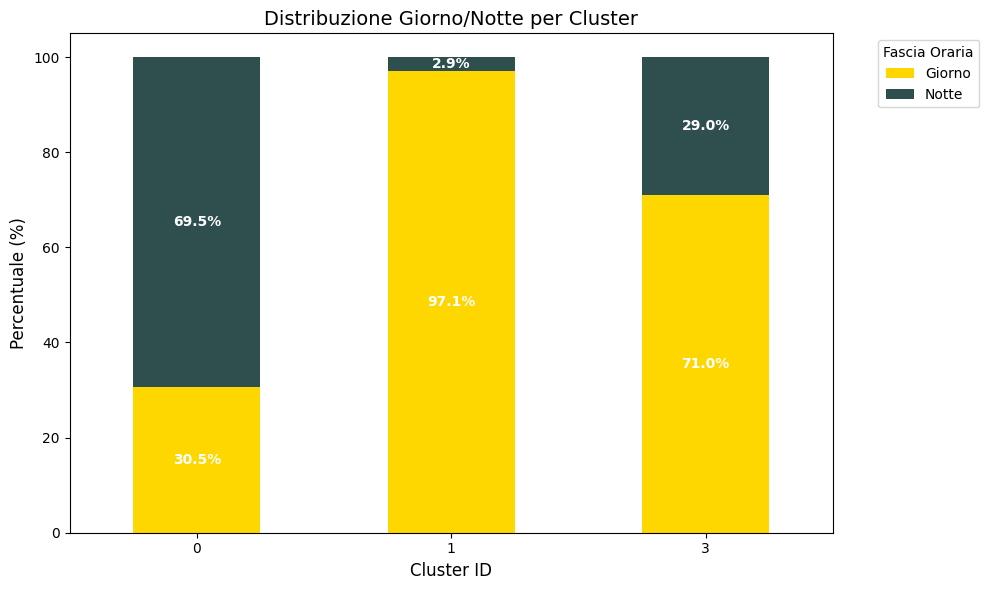

In [31]:
ax = percentuali.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#FFD700', '#2F4F4F'])

# Personalizzazione
plt.title('Distribuzione Giorno/Notte per Cluster', fontsize=14)
plt.ylabel('Percentuale (%)', fontsize=12)
plt.xlabel('Cluster ID', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Fascia Oraria', bbox_to_anchor=(1.05, 1), loc='upper left')

# Aggiunta delle etichette percentuali sulle barre
for c in ax.containers:
    # Aggiunge il testo sopra la barra se la percentuale è significativa
    ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

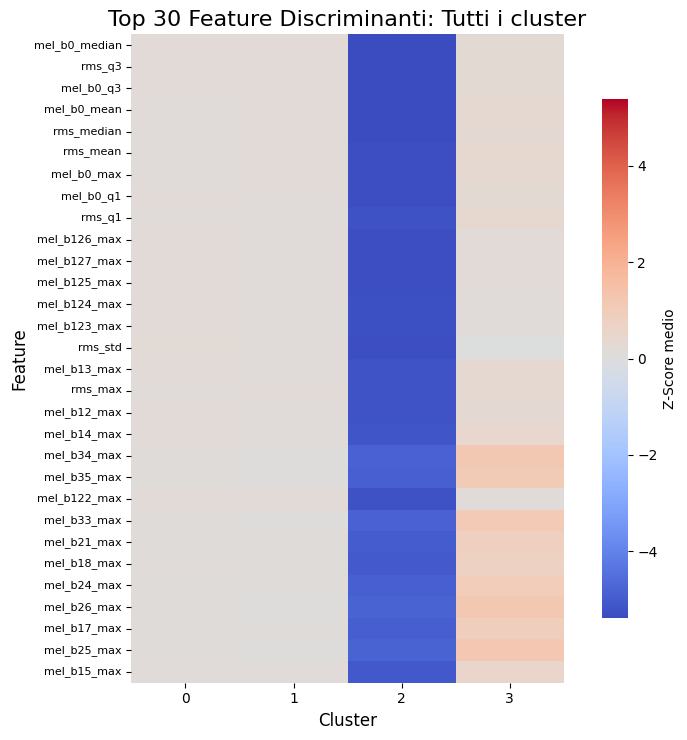

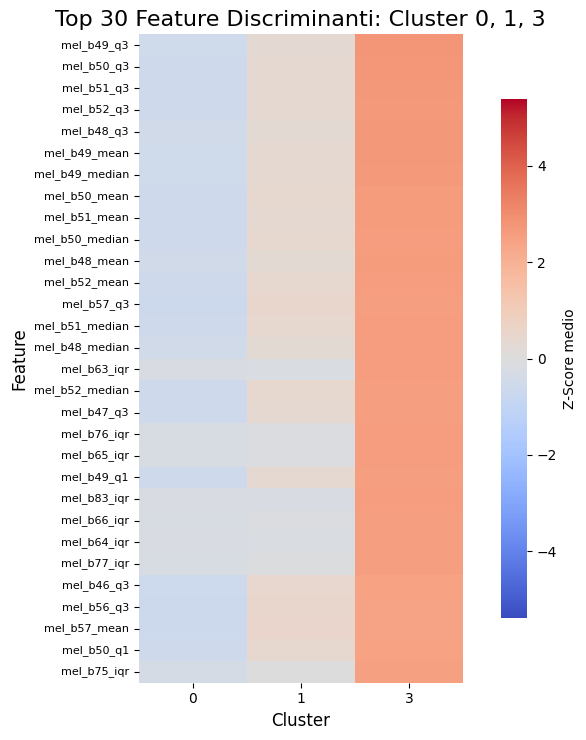

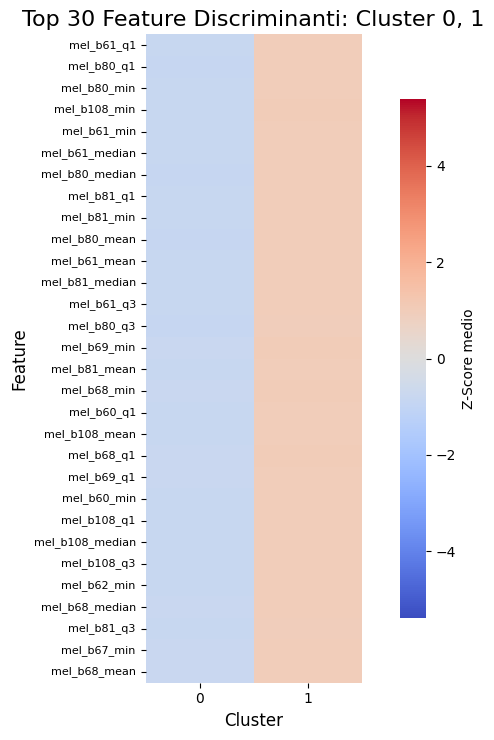

In [32]:
# Supponiamo che:
# X_original: DataFrame con le 1206 feature originali
# clusters: array/serie con le etichette assegnate da K-Means (0, 1, 2, 3)

# 1. Aggiungiamo le etichette di cluster al dataset originale
df_analysis = X_cleaned_scaled.copy()
df_analysis['cluster_kmeans'] = df_cleaned['cluster_kmeans']

# 1. Calcolo dei centroidi (già fatto)
centroids = df_analysis.groupby('cluster_kmeans').mean()

# Definizione delle combinazioni di cluster da analizzare
scenari = {
    "Tutti i cluster": [0, 1, 2, 3],
    "Cluster 0, 1, 3": [0, 1, 3],
    "Cluster 0, 1": [0, 1]
}

n_top = 30

vmax = centroids.abs().max().max()
vmin = -vmax


for nome, cluster_list in scenari.items():
    # 1. Filtriamo i centroidi per i cluster correnti
    subset_centroids = centroids.loc[cluster_list]

    # 2. Ricalcoliamo la varianza solo tra i cluster selezionati
    feature_variance_subset = subset_centroids.var(axis=0)
    top_features_subset = feature_variance_subset.nlargest(n_top).index
    top_centroids_subset = subset_centroids[top_features_subset]

    # 3. Creazione del grafico
    plt.figure(figsize=(8, n_top * 0.25))

    ax = sns.heatmap(top_centroids_subset.T,
                     cmap='coolwarm',
                     center=0,
                     vmin=vmin,  # <-- Fissiamo il minimo della scala
                     vmax=vmax,  # <-- Fissiamo il massimo della scala
                     annot=False,
                     cbar_kws={'label': 'Z-Score medio', 'shrink': 0.8, 'aspect': 20})

    # Impostiamo l'aspetto
    ax.set_aspect(0.2)

    plt.title(f'Top {n_top} Feature Discriminanti: {nome}', fontsize=16)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.yticks(rotation=0, fontsize=8)

    plt.tight_layout()
    plt.show()

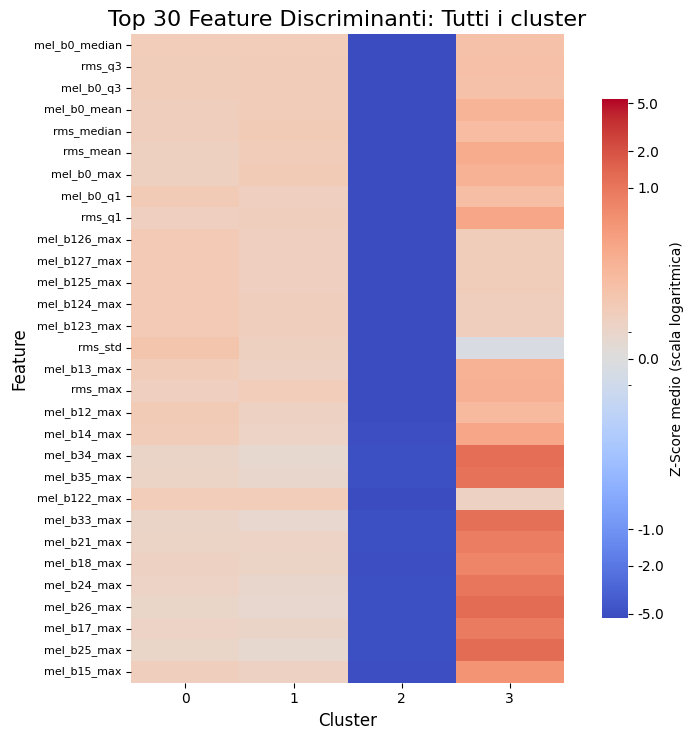

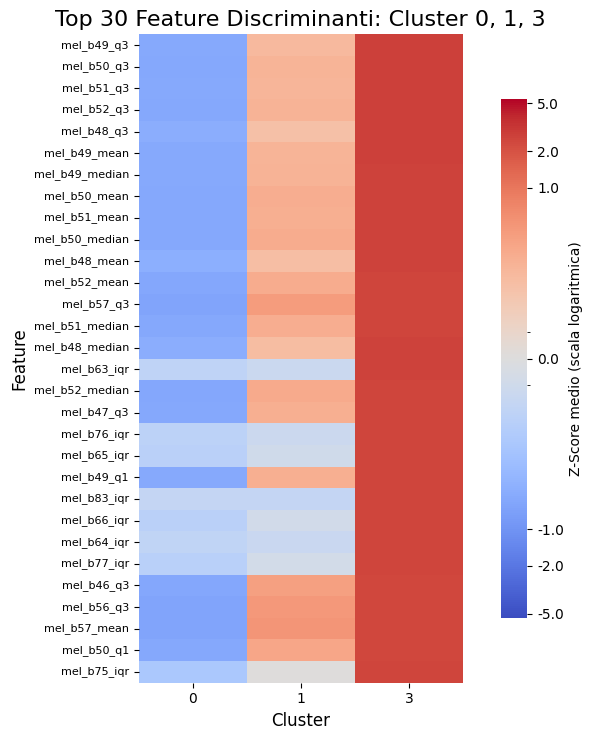

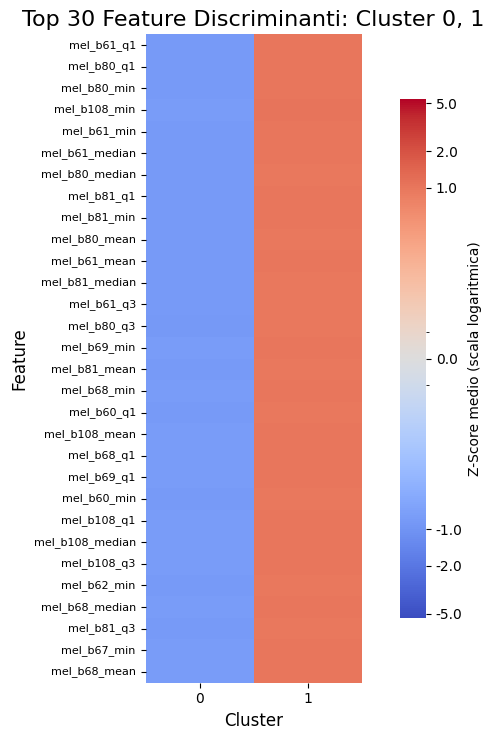

In [33]:
# Supponiamo che:
# X_original: DataFrame con le 1206 feature originali
# clusters: array/serie con le etichette assegnate da K-Means (0, 1, 2, 3)

# 1. Aggiungiamo le etichette di cluster al dataset originale
df_analysis = X_cleaned_scaled.copy()
df_analysis['cluster_kmeans'] = df_cleaned['cluster_kmeans']

# 1. Calcolo dei centroidi (già fatto)
centroids = df_analysis.groupby('cluster_kmeans').mean()

# Definizione delle combinazioni di cluster da analizzare
scenari = {
    "Tutti i cluster": [0, 1, 2, 3],
    "Cluster 0, 1, 3": [0, 1, 3],
    "Cluster 0, 1": [0, 1]
}

n_top = 30

vmax = centroids.abs().max().max()
vmin = -vmax


for nome, cluster_list in scenari.items():
    # 1. Filtriamo i centroidi per i cluster correnti
    subset_centroids = centroids.loc[cluster_list]

    # 2. Ricalcoliamo la varianza solo tra i cluster selezionati
    feature_variance_subset = subset_centroids.var(axis=0)
    top_features_subset = feature_variance_subset.nlargest(n_top).index
    top_centroids_subset = subset_centroids[top_features_subset]

    # 3. Creazione del grafico
    plt.figure(figsize=(8, n_top * 0.25))

    ax = sns.heatmap(top_centroids_subset.T,
                     cmap='coolwarm',
                     center=0,
                     vmin=vmin,  # <-- Fissiamo il minimo della scala
                     vmax=vmax,  # <-- Fissiamo il massimo della scala
                     annot=False,
                     norm=SymLogNorm(linthresh=0.5, vmin=vmin, vmax=vmax),  #Logaritmo in base 10
                     cbar_kws={'label': 'Z-Score medio (scala logaritmica)', 'shrink': 0.8, 'aspect': 20})


    cbar = ax.collections[0].colorbar
    
    # Decidi quali valori reali vuoi mostrare sulla legenda (es. estremi, zero e valori intermedi)
    tick_values = [np.ceil(vmin), -2, -1, 0, 1, 2, np.floor(vmax)]
    cbar.set_ticks(tick_values)
    
    # Formattiamo le etichette come numeri normali (es. con 1 decimale)
    cbar.set_ticklabels([f"{val:.1f}" for val in tick_values])

    # Impostiamo l'aspetto
    ax.set_aspect(0.2)

    plt.title(f'Top {n_top} Feature Discriminanti: {nome}', fontsize=16)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.yticks(rotation=0, fontsize=8)

    plt.tight_layout()
    plt.show()

In [34]:
print(f"Numero di feature in X_final_for_kmeans: {X_final_for_kmeans.shape[1]}")

Numero di feature in X_final_for_kmeans: 55


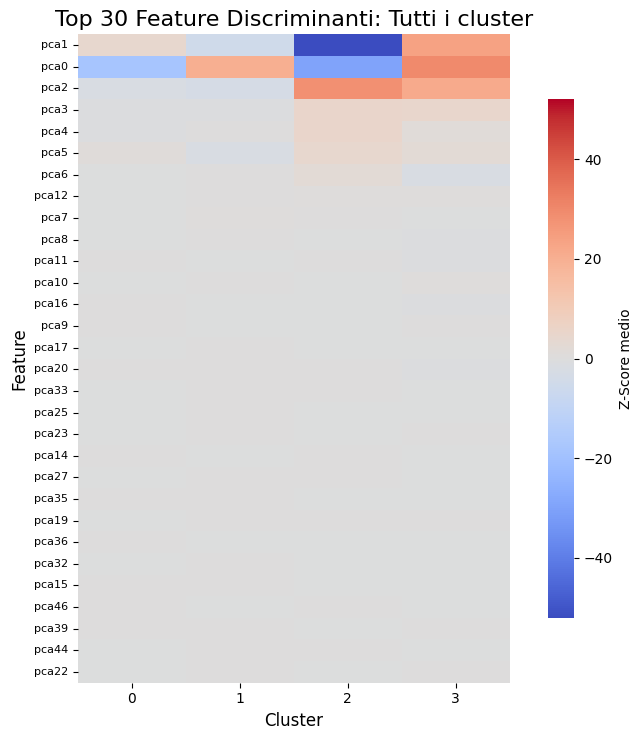

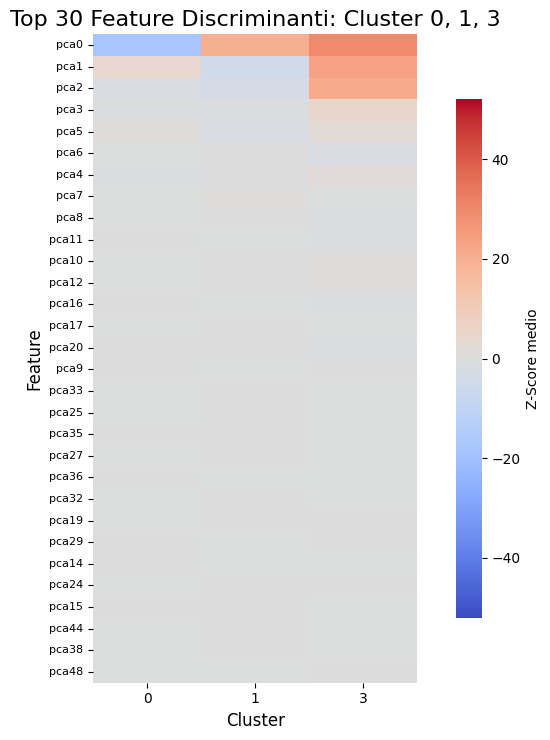

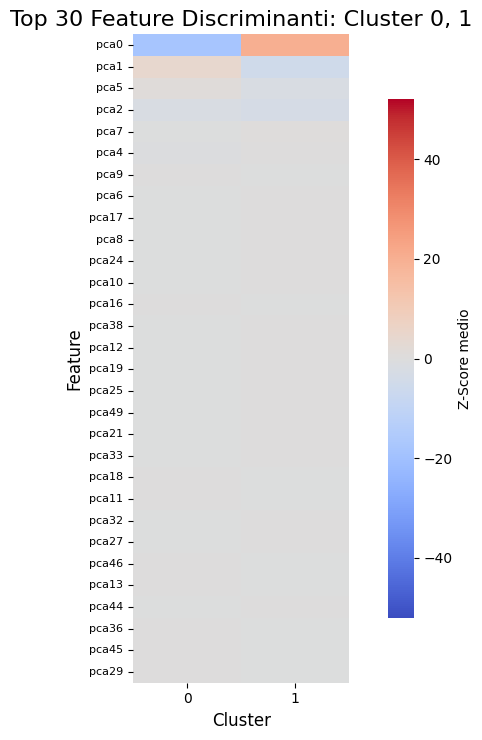

In [35]:
# Supponiamo che:
# X_original: DataFrame con le 1206 feature originali
# clusters: array/serie con le etichette assegnate da K-Means (0, 1, 2, 3)

# 1. Aggiungiamo le etichette di cluster al dataset originale
df_analysis = X_final_for_kmeans.copy()
df_analysis = df_analysis.join(df_cleaned['cluster_kmeans'])

# 1. Calcolo dei centroidi (già fatto)
centroids = df_analysis.groupby('cluster_kmeans').mean()

# Definizione delle combinazioni di cluster da analizzare
scenari = {
    "Tutti i cluster": [0, 1, 2, 3],
    "Cluster 0, 1, 3": [0, 1, 3],
    "Cluster 0, 1": [0, 1]
}

n_top = 30

vmax = centroids.abs().max().max()
vmin = -vmax

for nome, cluster_list in scenari.items():
    # 1. Filtriamo i centroidi per i cluster correnti
    subset_centroids = centroids.loc[cluster_list]

    # 2. Ricalcoliamo la varianza solo tra i cluster selezionati
    feature_variance_subset = subset_centroids.var(axis=0)
    top_features_subset = feature_variance_subset.nlargest(n_top).index
    top_centroids_subset = subset_centroids[top_features_subset]

    # 3. Creazione del grafico
    plt.figure(figsize=(8, n_top * 0.25))

    ax = sns.heatmap(top_centroids_subset.T,
                     cmap='coolwarm',
                     center=0,
                     vmin=vmin,  # <-- Fissiamo il minimo della scala
                     vmax=vmax,  # <-- Fissiamo il massimo della scala
                     annot=False,
                     cbar_kws={'label': 'Z-Score medio', 'shrink': 0.8, 'aspect': 20})

    # Impostiamo l'aspetto
    ax.set_aspect(0.2)

    plt.title(f'Top {n_top} Feature Discriminanti: {nome}', fontsize=16)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.yticks(rotation=0, fontsize=8)

    plt.tight_layout()
    plt.show()

In [36]:
assert df_analysis.index.equals(df_cleaned.index)

In [37]:
print("Colonne di df_cleaned:", df_cleaned.columns.tolist())
print("Numero di colonne in df_cleaned:", len(df_cleaned.columns))
print("Colonne di metadata_df:", metadata_df.columns.tolist())
print("Numero di colonne in metadata_df:", len(metadata_df.columns))

Colonne di df_cleaned: ['ae_mean', 'ae_std', 'ae_min', 'ae_max', 'ae_q1', 'ae_median', 'ae_q3', 'ae_iqr', 'ae_delta_mean', 'rms_mean', 'rms_std', 'rms_min', 'rms_max', 'rms_q1', 'rms_median', 'rms_q3', 'rms_iqr', 'rms_delta_mean', 'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'zcr_q1', 'zcr_median', 'zcr_q3', 'zcr_iqr', 'zcr_delta_mean', 'ber_mean', 'ber_std', 'ber_min', 'ber_max', 'ber_q1', 'ber_median', 'ber_q3', 'ber_iqr', 'ber_delta_mean', 'sc_mean', 'sc_std', 'sc_min', 'sc_max', 'sc_q1', 'sc_median', 'sc_q3', 'sc_iqr', 'sc_delta_mean', 'bw_mean', 'bw_std', 'bw_min', 'bw_max', 'bw_q1', 'bw_median', 'bw_q3', 'bw_iqr', 'bw_delta_mean', 'mel_b0_mean', 'mel_b0_std', 'mel_b0_min', 'mel_b0_max', 'mel_b0_q1', 'mel_b0_median', 'mel_b0_q3', 'mel_b0_iqr', 'mel_b0_delta_mean', 'mel_b1_mean', 'mel_b1_std', 'mel_b1_min', 'mel_b1_max', 'mel_b1_q1', 'mel_b1_median', 'mel_b1_q3', 'mel_b1_iqr', 'mel_b1_delta_mean', 'mel_b2_mean', 'mel_b2_std', 'mel_b2_min', 'mel_b2_max', 'mel_b2_q1', 'mel_b2_median'

In [38]:
if WANT_TO_SAVE:
    filtered_filenames = df_cleaned[df_cleaned[f'cluster_kmeans'].isin(PREFERRED_CLUSTERS)].index.tolist()
    filtered_metadata_df = metadata_df[metadata_df['filename'].isin(filtered_filenames)].copy()

    filtered_metadata_df.to_csv(CSV_OUTPUT_PATH, index=False)

In [39]:
if WANT_TO_SAVE:
    print("Colonne di filtered_metadata_df:", filtered_metadata_df.columns.tolist())
    print("Numero di colonne in filtered_metadata_df:", len(filtered_metadata_df.columns))

Colonne di filtered_metadata_df: ['original_filename', 'filename', 'sha256_hash', 'timestamp']
Numero di colonne in filtered_metadata_df: 4


In [40]:
if WANT_TO_SAVE:
    # Definiamo gli algoritmi e le relative colonne nel DataFrame
    algorithms = {
        "KMeans": "cluster_kmeans"
    }

    print(f"Inizio smistamento file in {OUTPUT_BASE_DIR}...")

    # Iteriamo sui due metodi di clustering
    for nome_algoritmo, colonna_cluster in algorithms.items():
        print(f"Elaborazione cartelle per {nome_algoritmo}...")

        # 1. Identifichiamo i cluster unici prodotti dall'algoritmo
        cluster_unici = df_cleaned[colonna_cluster].unique()

        for cluster_id in cluster_unici:
            # 2. Creiamo il nome della sottocartella
            # Se è HDBSCAN e il cluster è -1, lo chiamiamo Outliers
            if nome_algoritmo == "HDBSCAN" and cluster_id == -1:
                nome_cartella = "Outliers"
            else:
                nome_cartella = f"Cluster_{cluster_id}"

            target_dir = OUTPUT_BASE_DIR / nome_algoritmo / nome_cartella
            target_dir.mkdir(parents=True, exist_ok=True)

            # 3. Filtriamo i file appartenenti a questo specifico cluster
            file_nel_cluster = df_cleaned[df_cleaned[colonna_cluster] == cluster_id].index

            # 4. Copia fisica dei file
            for nome_file in file_nel_cluster:
                src_path = SOURCE_DIR / nome_file
                dest_path = target_dir / nome_file

                if src_path.exists():
                    shutil.copy2(src_path, dest_path)
                else:
                    # Opzionale: stampa se manca qualche file sorgente
                    print(f"File non trovato: {nome_file}")

Inizio smistamento file in Clustered_Audio...
Elaborazione cartelle per KMeans...


In [41]:
if WANT_TO_SAVE:
    # Copia dei file outlier in una cartella separata
    outlier_dir = OUTPUT_BASE_DIR / "HDBSCAN" / "Outliers"
    outlier_dir.mkdir(parents=True, exist_ok=True)

    for nome_file in df_outliers.index.tolist():
        src_path = SOURCE_DIR / nome_file
        dest_path = outlier_dir / nome_file

        if src_path.exists():
            shutil.copy2(src_path, dest_path)
        else:
            print(f"File non trovato (outlier): {nome_file}")

In [42]:
if WANT_TO_SAVE:
    # 3. Estrai la lista dei nomi file dal df filtrato
    # Assumendo che la colonna si chiami 'filename'
    files_to_copy = filtered_metadata_df['filename'].tolist()

    print(f"Inizio copia di {len(files_to_copy)} file...")

    contatore_successi = 0
    contatore_errori = 0

    for filename in files_to_copy:
        source_path = SOURCE_DIR / filename
        target_path = FILTERED_DIR / filename

        # Verifica se il file esiste nella sorgente
        if source_path.exists():
            shutil.copy2(source_path, target_path)  # copy2 preserva anche i metadati (date, ecc.)
            contatore_successi += 1
        else:
            print(f"File non trovato: {filename}")
            contatore_errori += 1

    print(f"Operazione completata!")
    print(f"File copiati: {contatore_successi}")
    if contatore_errori > 0:
        print(f"File mancanti: {contatore_errori}")

Inizio copia di 2398 file...
Operazione completata!
File copiati: 2398
